# Análisis Exploratorio de Datos - Datos de astronomía.txt

Este notebook realiza un análisis exploratorio completo del archivo de datos, utilizando todas las funciones disponibles en `data_explorer.py` para una revisión exhaustiva de los datos.

## 0. Instalación de Dependencias

In [18]:
import subprocess
import sys

# Instalar dependencias requeridas
subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt", "-q"])


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


0

## 1. Importar Librerías

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_explorer import DataExplorer
import warnings

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
warnings.filterwarnings('ignore')

## 2. Cargar y Explorar Datos

In [38]:
# pip install astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 51.2 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 33.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 41.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 738.7/738.7 kB 32.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 38.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 61.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [astroquery]4 [astroquery]y]data]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [39]:
# Datos de astronomía - variable a pronosticar "pl_bmassj"

from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
import pandas as pd
 
cols = [
    "pl_name","pl_bmassj","pl_rade","pl_orbper","pl_orbsmax","pl_eqt","pl_insol",
    "st_mass","st_rad","st_teff","st_met"
]
 
# Tabla recomendada: pscomppars (composite parameters)
qt = NasaExoplanetArchive.query_criteria(
    table="pscomppars",
    select=",".join(cols),
    where="pl_bmassj is not null and pl_rade is not null"
)
 
df = qt.to_pandas()
df.shape, df.head()

((6086, 11),
          pl_name  pl_bmassj   pl_rade  pl_orbper  pl_orbsmax  pl_eqt  \
 0  Kepler-1167 b    0.01120  1.710000   1.003934     0.01750  1419.0   
 1  Kepler-1740 b    0.03470  3.323214   8.172400     0.07790   858.0   
 2  Kepler-1581 b    0.00137  0.800000   6.283855     0.06865  1108.0   
 3   Kepler-644 b    0.03170  3.150000   3.173917     0.04641  1655.0   
 4  Kepler-1752 b    0.05900  4.540605  56.358501     0.26980   419.0   
 
    pl_insol  st_mass  st_rad  st_teff  st_met  
 0  1039.697    0.790   0.750   4971.0   -0.05  
 1   127.950    0.943   0.905   5705.0   -0.06  
 2   470.862    1.120   1.230   6022.0    0.07  
 3  2381.770    1.490   1.810   6747.0    0.08  
 4     7.290    0.824   0.821   5446.0   -0.20  )

## 3. Vista Previa de Datos

In [56]:
print("\\n=== TAMAÑO ===")
print(df.shape)

print("\\n=== PRIMERAS FILAS ===")
print(df.head(10))

print("\\n=== ÚLTIMAS FILAS ===")
print(df.tail())

print("\\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df.describe())

print("\\n=== TIPOS DE DATOS ===")
print(df.dtypes)

print("\\n=== INFORMACIÓN GENERAL ===")
print(df.info())

\n=== TAMAÑO ===
(6086, 11)
\n=== PRIMERAS FILAS ===
         pl_name  pl_bmassj    pl_rade  pl_orbper  pl_orbsmax  pl_eqt  \
0  Kepler-1167 b    0.01120   1.710000   1.003934     0.01750  1419.0   
1  Kepler-1740 b    0.03470   3.323214   8.172400     0.07790   858.0   
2  Kepler-1581 b    0.00137   0.800000   6.283855     0.06865  1108.0   
3   Kepler-644 b    0.03170   3.150000   3.173917     0.04641  1655.0   
4  Kepler-1752 b    0.05900   4.540605  56.358501     0.26980   419.0   
5   Kepler-280 c    0.01480   2.010000   4.807091     0.05600  1088.0   
6  Kepler-1208 b    0.01890   2.320000  11.085076     0.09010   665.0   
7   Kepler-263 c    0.02100   2.470000  47.332773     0.24200   386.0   
8  Kepler-1101 b    0.02100   2.470000  81.315106     0.34830   393.0   
9    HD 168746 b    0.27000  11.100000   6.404000     0.07000   900.0   

   pl_insol  st_mass  st_rad  st_teff  st_met  
0  1039.697    0.790   0.750   4971.0 -0.0500  
1   127.950    0.943   0.905   5705.0 -0.0600  

## 4. Crear Instancia de DataExplorer

In [42]:
explorer = DataExplorer(df, verbose=True)

## 5. Resumen Estructural de Datos

In [59]:
resumen_estructural = explorer.get_structural_summary()


=== Structural Summary ===
                    metric   value
                Total rows    6086
             Total columns      11
              Memory usage 0.82 MB
           Numeric columns      10
       Categorical columns       0
           Boolean columns       0
          Datetime columns       0
         Free-text columns       0
Unknown/mixed type columns       1
Large dataset (rows >500k)   False
   Wide dataset (cols >50)   False


## 6. Análisis de Valores Faltantes

In [44]:
analisis_nulos = explorer.analyze_nulls()
print("Análisis de Valores Faltantes:")
print(analisis_nulos)


=== Null Analysis ===
            null_count   null_pct
pl_insol          1800  29.576076
pl_eqt            1526  25.073940
st_met             549   9.020703
pl_orbper          336   5.520868
st_rad             314   5.159382
pl_orbsmax         306   5.027933
st_teff            293   4.814328
st_mass              6   0.098587
pl_rade              0   0.000000
pl_name              0   0.000000
pl_bmassj            0   0.000000
Análisis de Valores Faltantes:
            null_count   null_pct
pl_insol          1800  29.576076
pl_eqt            1526  25.073940
st_met             549   9.020703
pl_orbper          336   5.520868
st_rad             314   5.159382
pl_orbsmax         306   5.027933
st_teff            293   4.814328
st_mass              6   0.098587
pl_rade              0   0.000000
pl_name              0   0.000000
pl_bmassj            0   0.000000


## 7. Análisis de Duplicados

In [ ]:
explorer.id_col

In [45]:
analisis_duplicados = explorer.analyze_duplicates()
print("Análisis de Duplicados:")
for key, value in analisis_duplicados.items():
    print(f"  {key}: {value}")


=== Duplicate Analysis ===
  Full duplicate rows: 0
Análisis de Duplicados:
  full_duplicates: 0
  id_duplicates: None
  duplicated_ids: None


## 8. Detección de Variables con Baja Varianza

In [46]:
bajo_varianza = explorer.detect_low_variance()
print(f"Variables con baja varianza detectadas: {len(bajo_varianza)}")
if bajo_varianza:
    print("Columnas:", bajo_varianza)


=== Low Variance Detection ===
  No low-variance columns detected.
Variables con baja varianza detectadas: 0


## 9. Detección de Outliers

In [47]:
outliers_df = explorer.detect_outliers()
print(f"Total de outliers detectados: {len(outliers_df)}\\n")
if len(outliers_df) > 0:
    print(outliers_df.head(10))


=== Outlier Detection ===
  Method: iqr, threshold: 1.5
            n_outliers  pct_outliers  lower_bound  upper_bound
column                                                        
pl_bmassj          995         16.35      -0.8314       1.4208
pl_rade              4          0.07     -13.3000      27.0200
pl_orbper          996         17.32     -48.4097      92.2836
pl_orbsmax        1054         18.24      -0.3267       0.6841
pl_eqt             101          2.21    -329.5000    2058.5000
pl_insol           508         11.85    -502.9021     900.7757
st_mass            416          6.84       0.2900       1.5700
st_rad             381          6.60       0.0500       1.9700
st_teff            254          4.38    3395.0000    7403.0000
st_met             188          3.40      -0.3950       0.4450
Total de outliers detectados: 10\n
            n_outliers  pct_outliers  lower_bound  upper_bound
column                                                        
pl_bmassj          995    

## 10. Análisis de Normalidad - Gráficos Q-Q

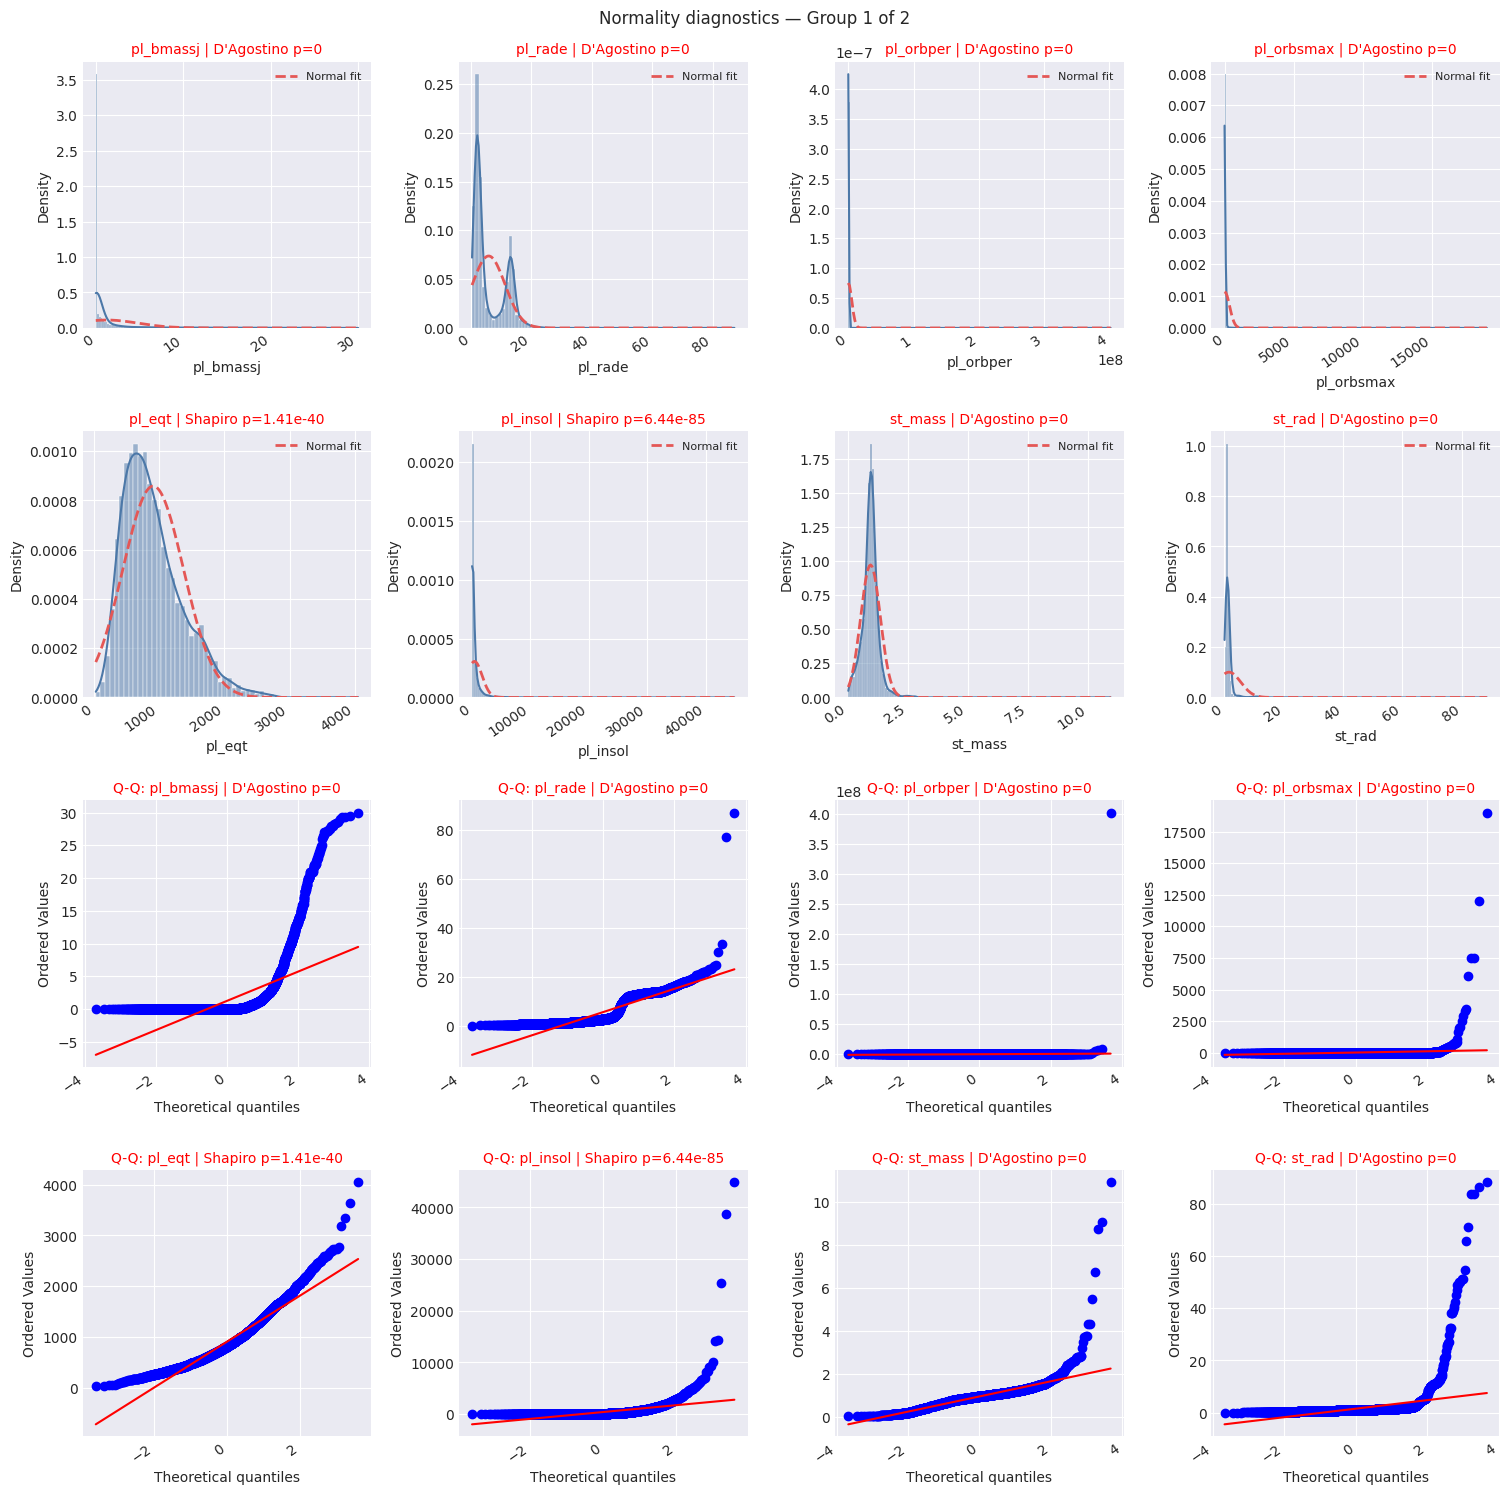

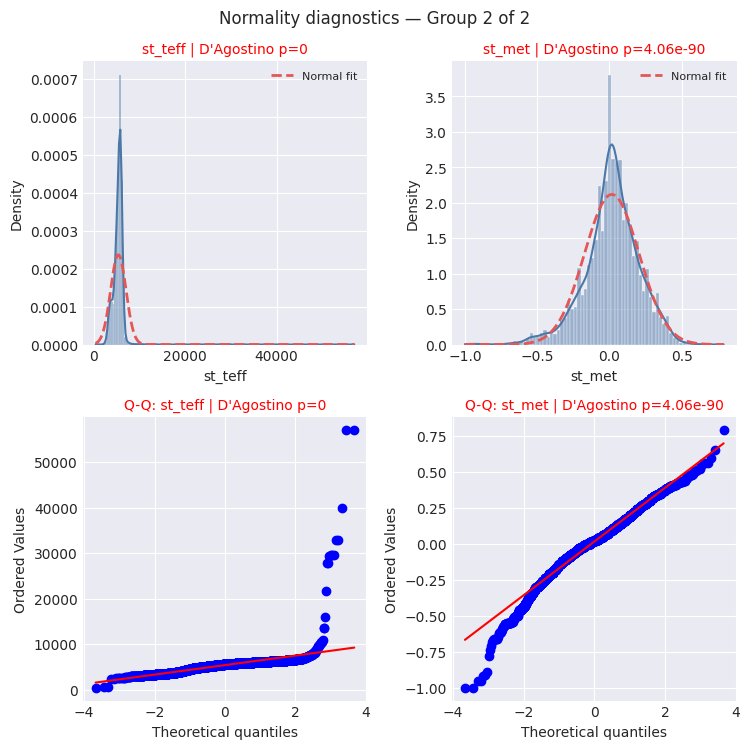

<Figure size 640x480 with 0 Axes>

In [48]:
fig = explorer.plot_normality()
plt.tight_layout()
plt.show()

## 11. Matriz de Correlación

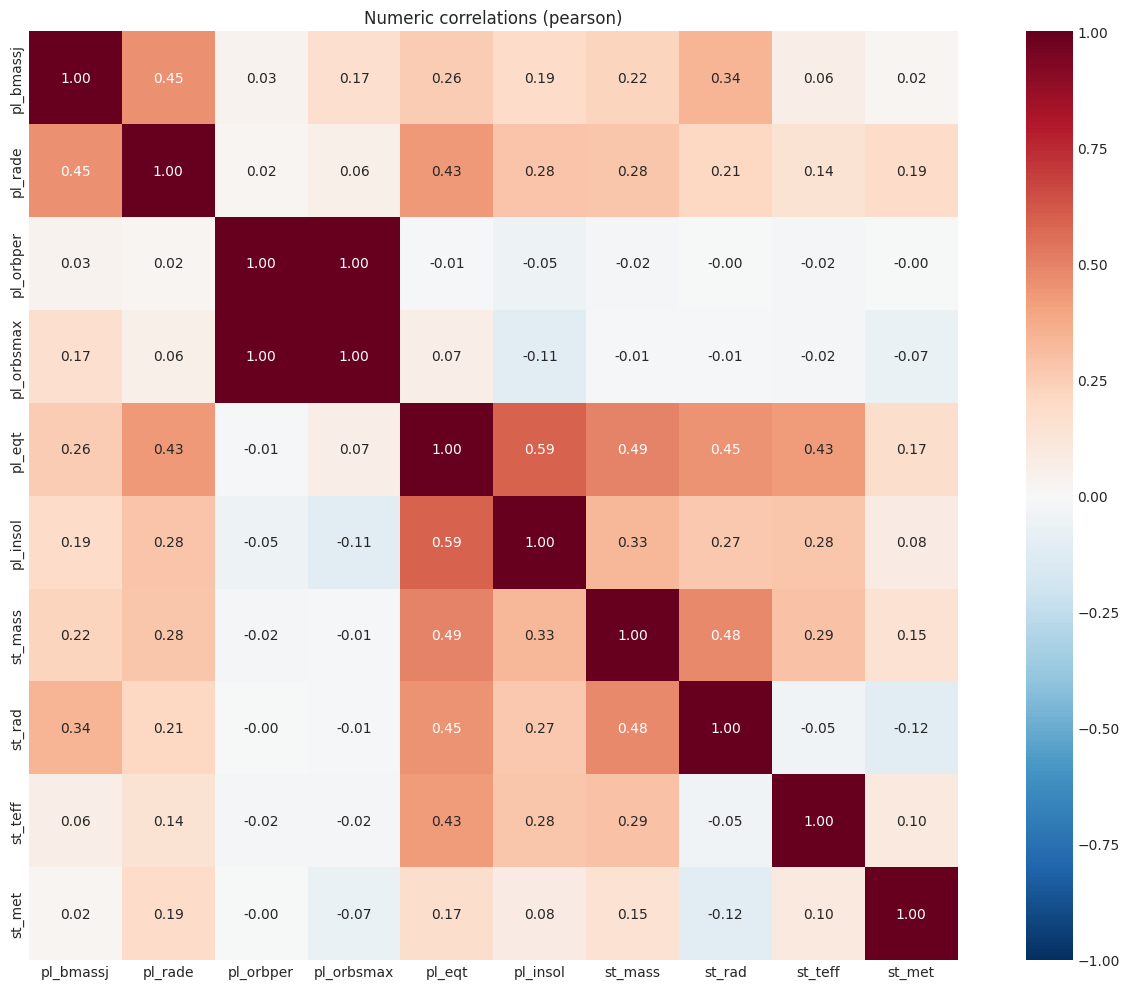

<Figure size 640x480 with 0 Axes>

In [49]:
fig = explorer.plot_correlation_heatmap()
plt.tight_layout()
plt.show()

## 12. Gráficos Scatter de Relaciones Bivariadas

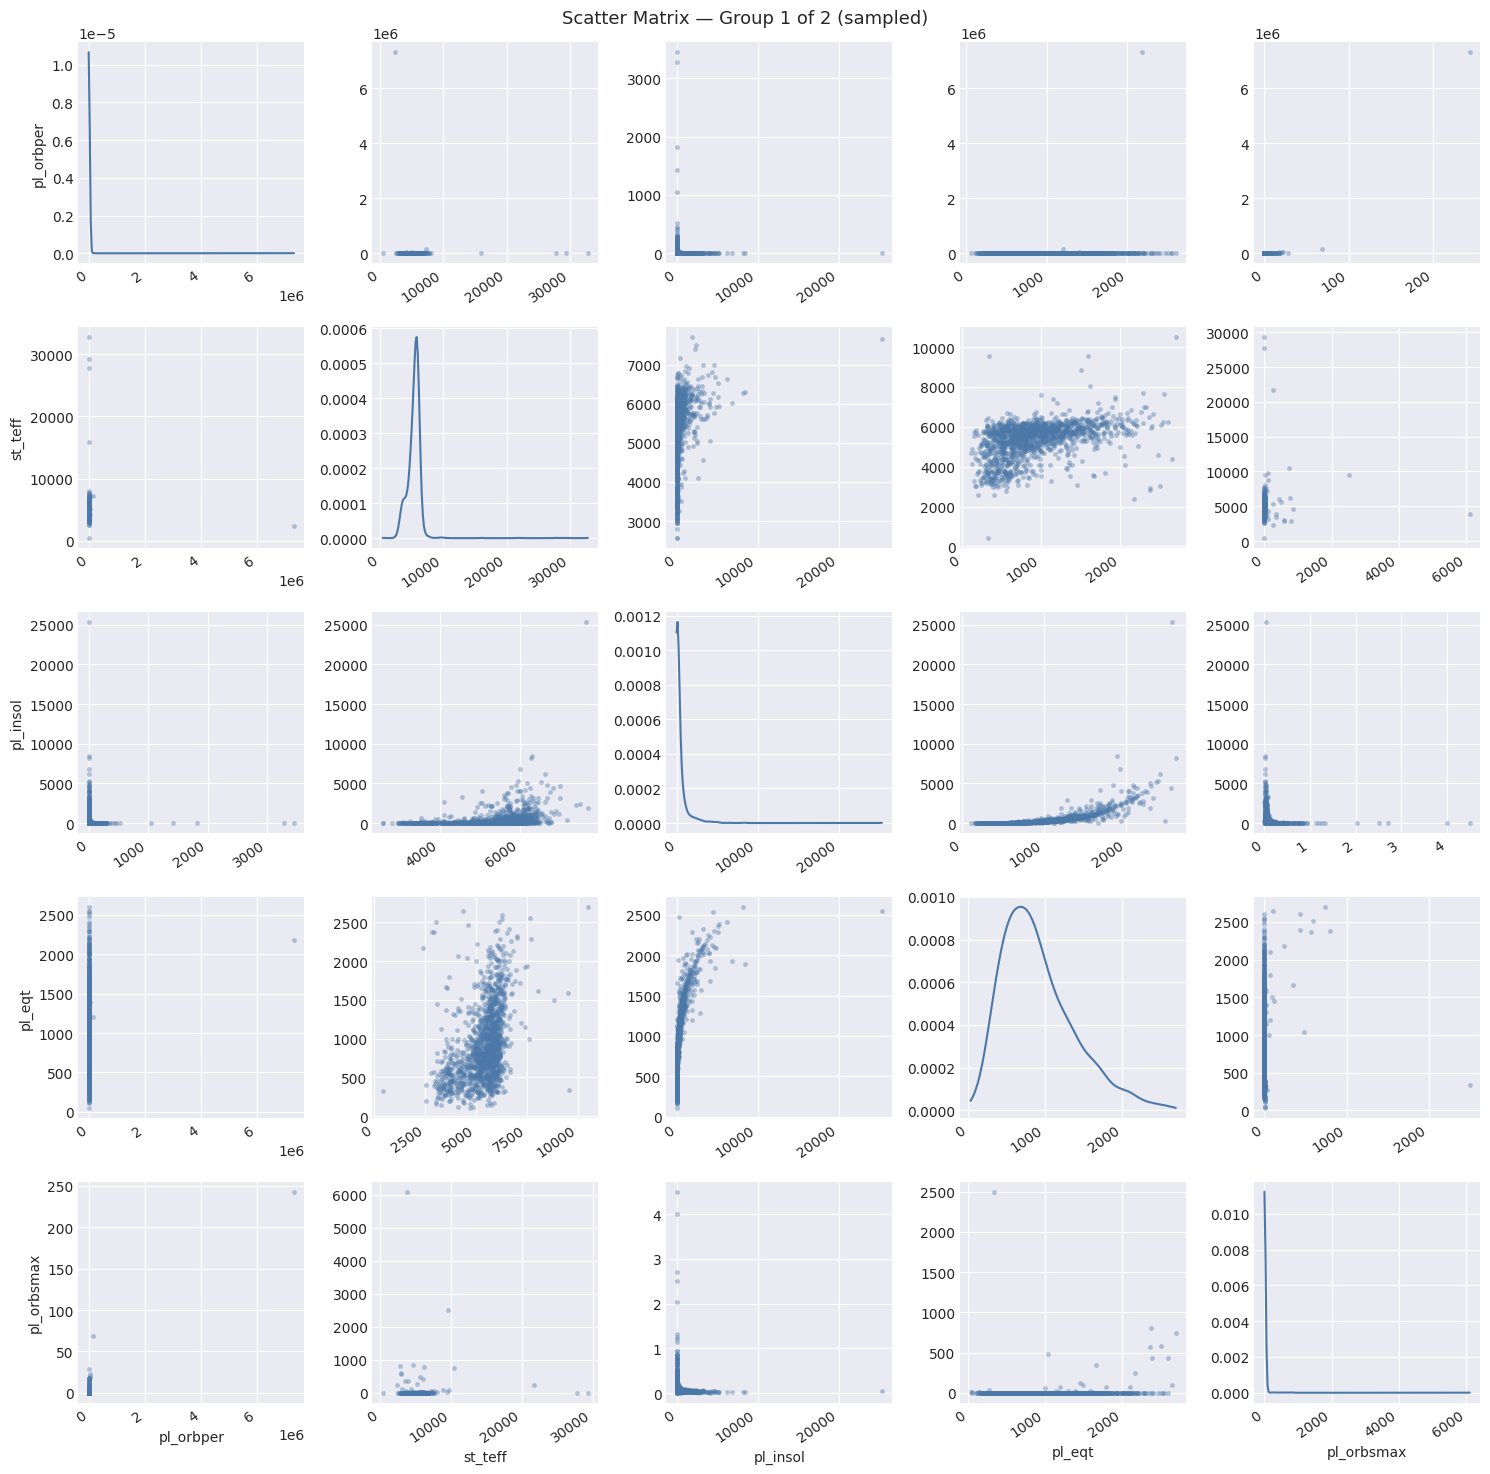

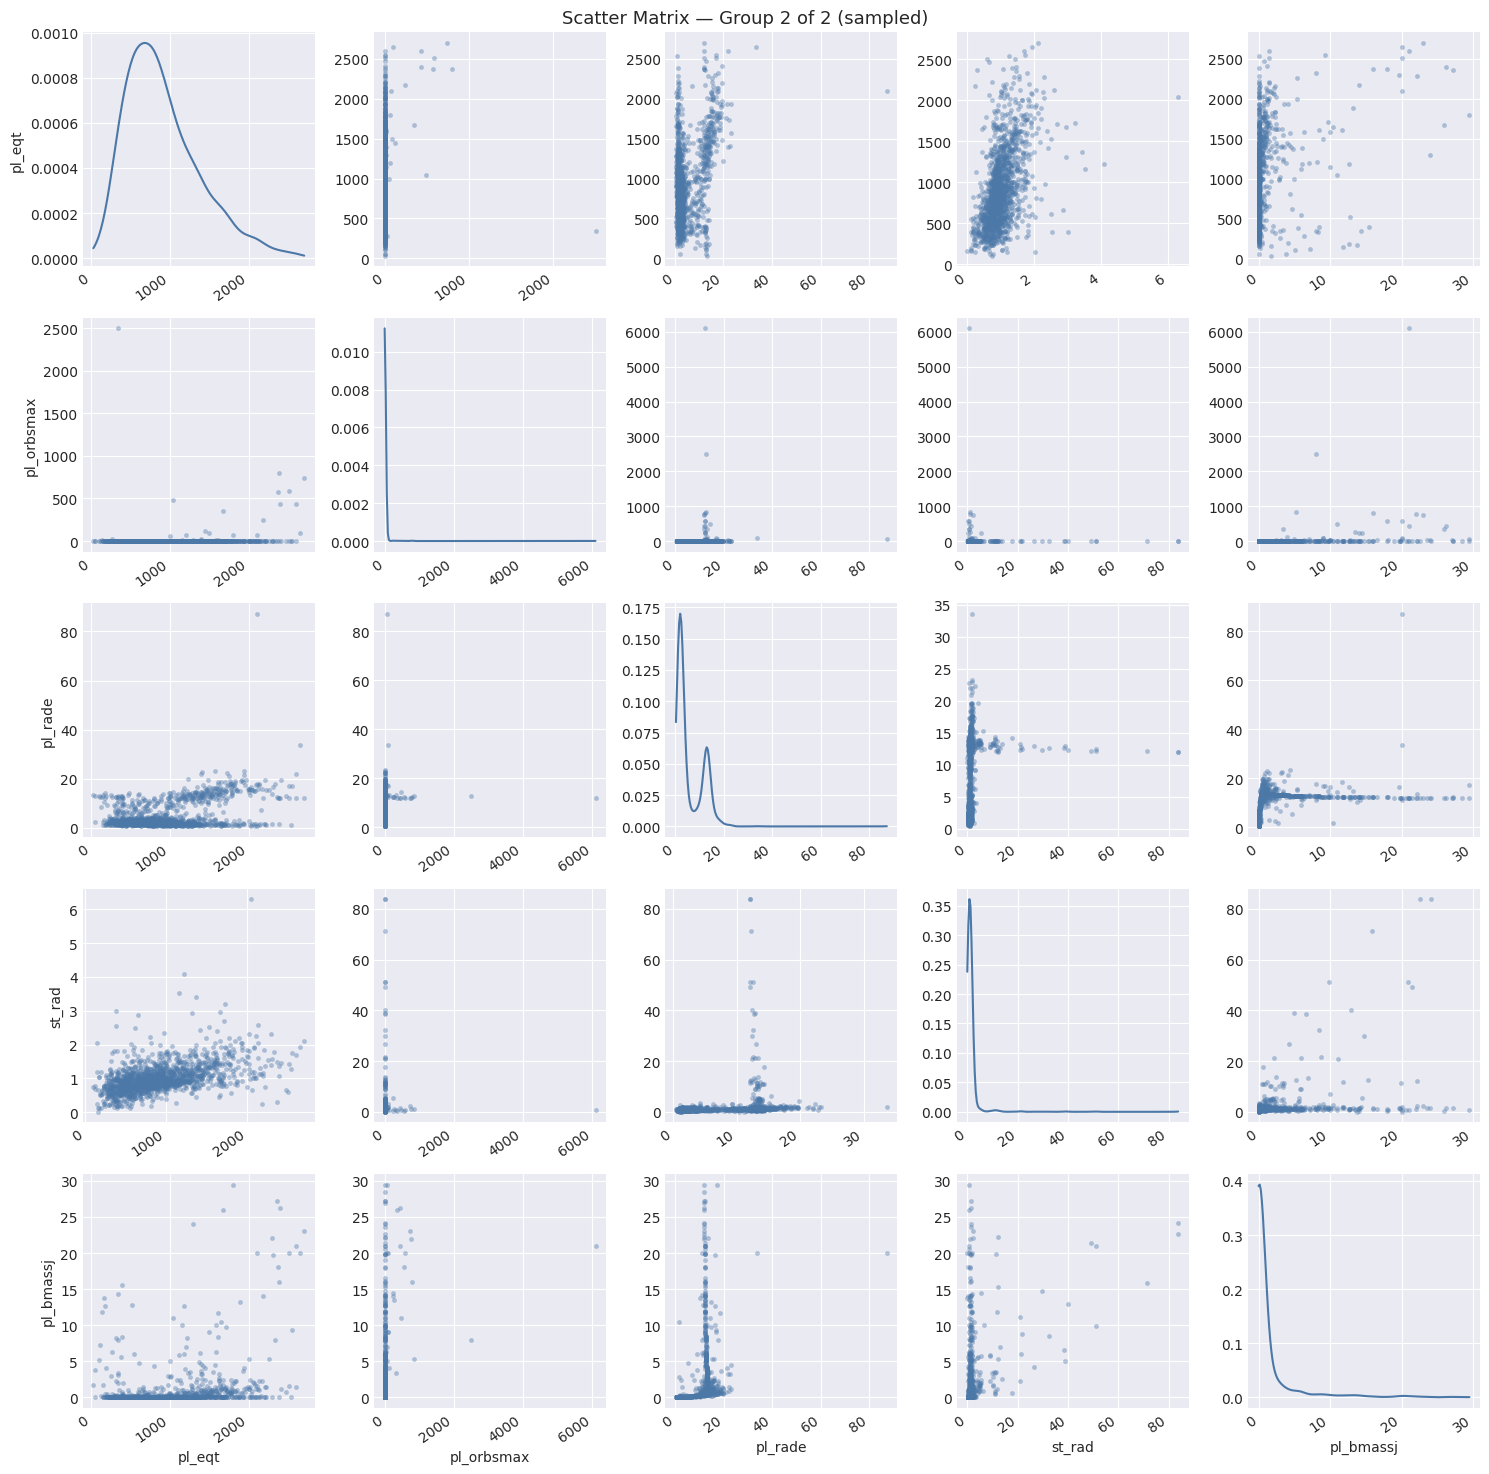

<Figure size 640x480 with 0 Axes>

In [50]:
try:
    fig = explorer.plot_scatter()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Nota: No se pudieron generar scatter plots. Razón: {str(e)[:100]}")

## 13. Resumen de Alertas y Problemas Detectados

In [51]:
alerts_df = explorer.generate_alert_summary()
print(f"Total de alertas: {len(alerts_df)}\\n")
if len(alerts_df) > 0:
    print(alerts_df)


=== Alert Summary ===
severity  category                                                                                                                                                                            message                                                                              affected_columns
 WARNING  outliers                                                                                                                                      Column 'pl_bmassj' has 16.35% outliers (>10%)                                                                                     pl_bmassj
 WARNING  outliers                                                                                                                                      Column 'pl_orbper' has 17.32% outliers (>10%)                                                                                     pl_orbper
 WARNING  outliers                                                                                   

## 14. Pipeline Summary para Downstream Processing

In [52]:
pipeline_summary = explorer.get_pipeline_summary()
print("Pipeline Summary para Downstream Processing:")
print(f"  Número de variables numéricas: {len(pipeline_summary['numeric_cols'])}")
print(f"  Número de variables categóricas: {len(pipeline_summary['categorical_cols'])}")
print(f"  Columnas con valores faltantes: {len(pipeline_summary['null_columns'])}")
print(f"  Columnas de baja varianza: {len(pipeline_summary['low_variance_cols'])}")
print(f"\\nVARIABLES NUMÉRICAS:")
print(pipeline_summary['numeric_cols'][:10])
print(f"\\nVARIABLES CATEGÓRICAS:")
print(pipeline_summary['categorical_cols'][:10])


=== Low Variance Detection ===
  No low-variance columns detected.

=== Outlier Detection ===
  Method: iqr, threshold: 1.5
            n_outliers  pct_outliers  lower_bound  upper_bound
column                                                        
pl_bmassj          995         16.35      -0.8314       1.4208
pl_rade              4          0.07     -13.3000      27.0200
pl_orbper          996         17.32     -48.4097      92.2836
pl_orbsmax        1054         18.24      -0.3267       0.6841
pl_eqt             101          2.21    -329.5000    2058.5000
pl_insol           508         11.85    -502.9021     900.7757
st_mass            416          6.84       0.2900       1.5700
st_rad             381          6.60       0.0500       1.9700
st_teff            254          4.38    3395.0000    7403.0000
st_met             188          3.40      -0.3950       0.4450

=== Duplicate Analysis ===
  Full duplicate rows: 0

=== Tidy Format Check ===
Dataset appears to be in tidy format.



## 15. Análisis EDA Completo


=== Tidy Format Check ===
Dataset appears to be in tidy format.

=== Structural Summary ===
                    metric   value
                Total rows    6086
             Total columns      11
              Memory usage 0.82 MB
           Numeric columns      10
       Categorical columns       0
           Boolean columns       0
          Datetime columns       0
         Free-text columns       0
Unknown/mixed type columns       1
Large dataset (rows >500k)   False
   Wide dataset (cols >50)   False

=== Null Analysis ===
            null_count   null_pct
pl_insol          1800  29.576076
pl_eqt            1526  25.073940
st_met             549   9.020703
pl_orbper          336   5.520868
st_rad             314   5.159382
pl_orbsmax         306   5.027933
st_teff            293   4.814328
st_mass              6   0.098587
pl_rade              0   0.000000
pl_name              0   0.000000
pl_bmassj            0   0.000000

=== Duplicate Analysis ===
  Full duplicate rows: 0

==

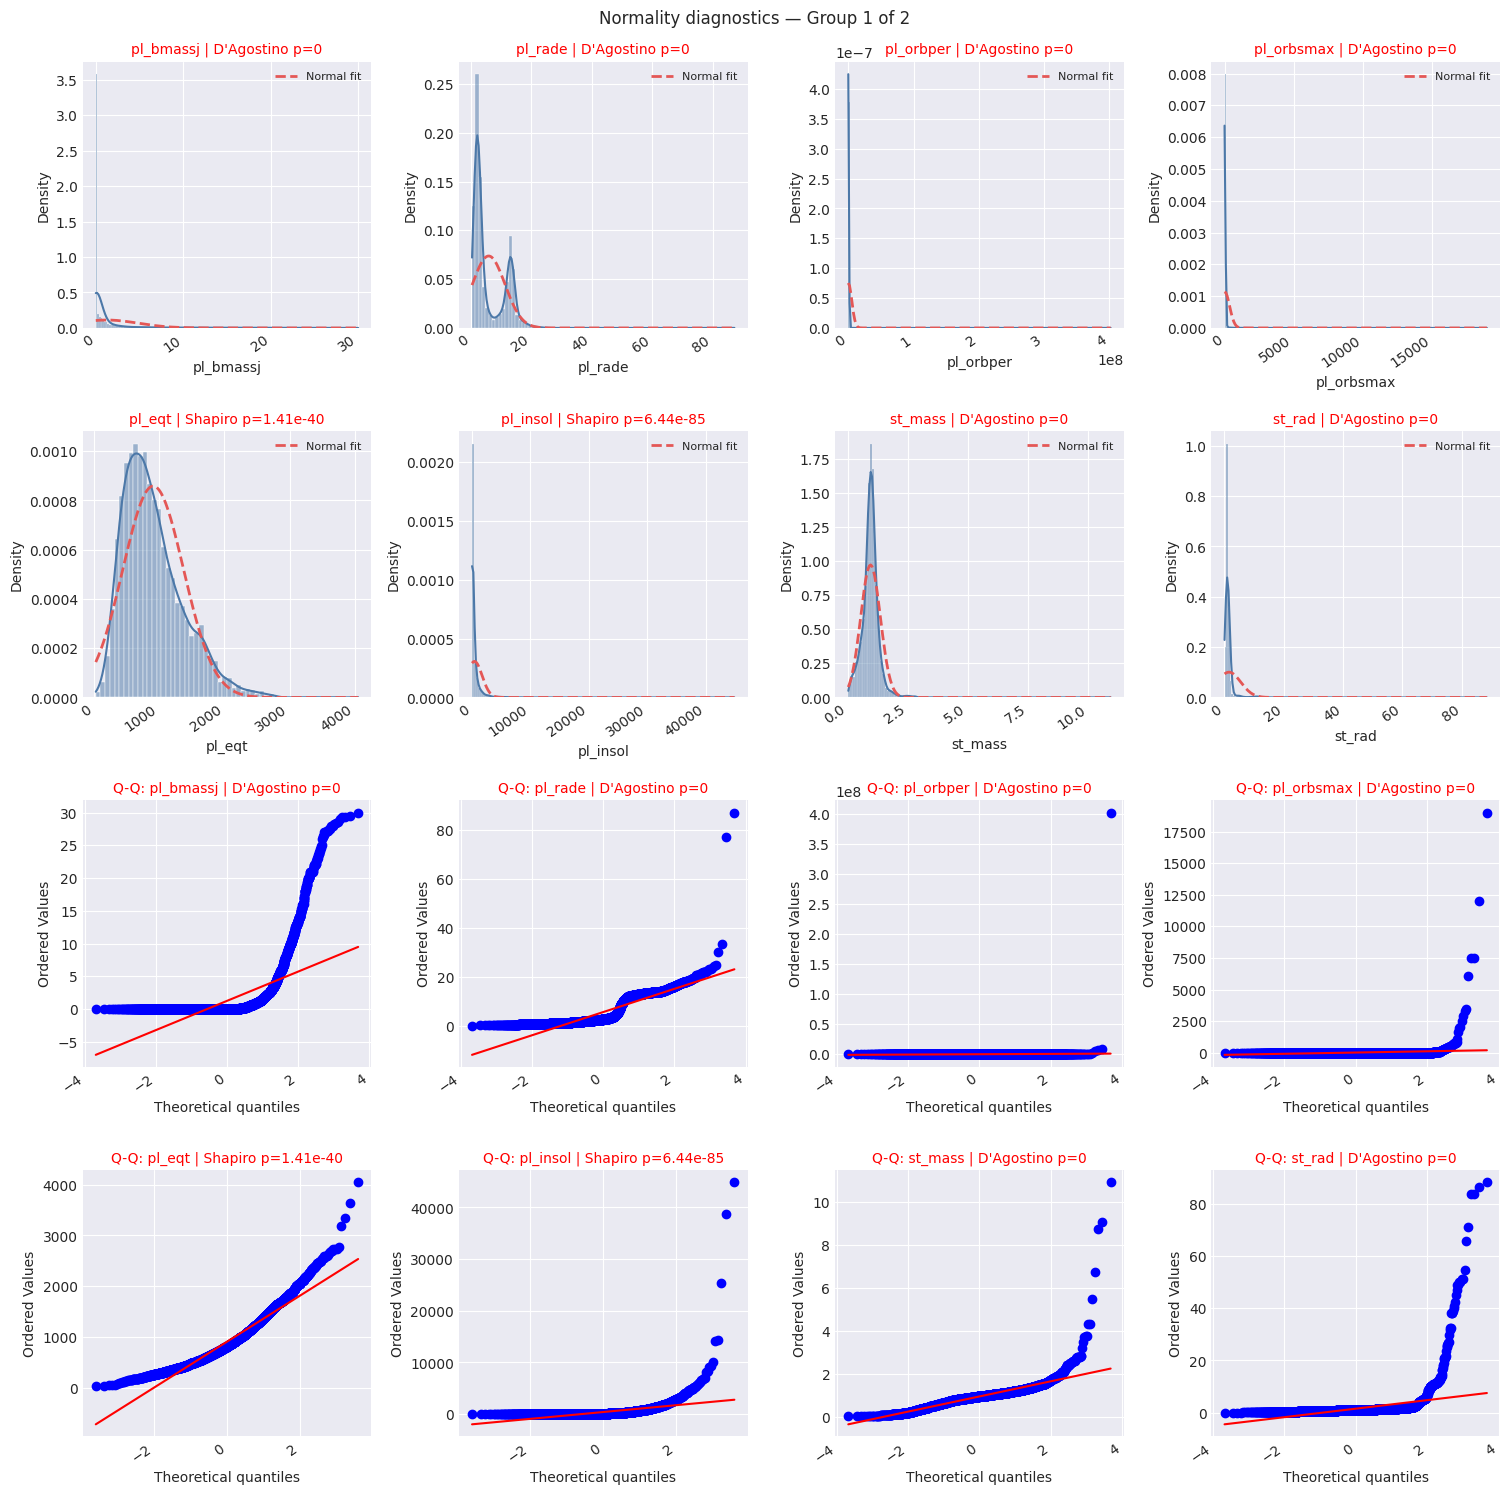

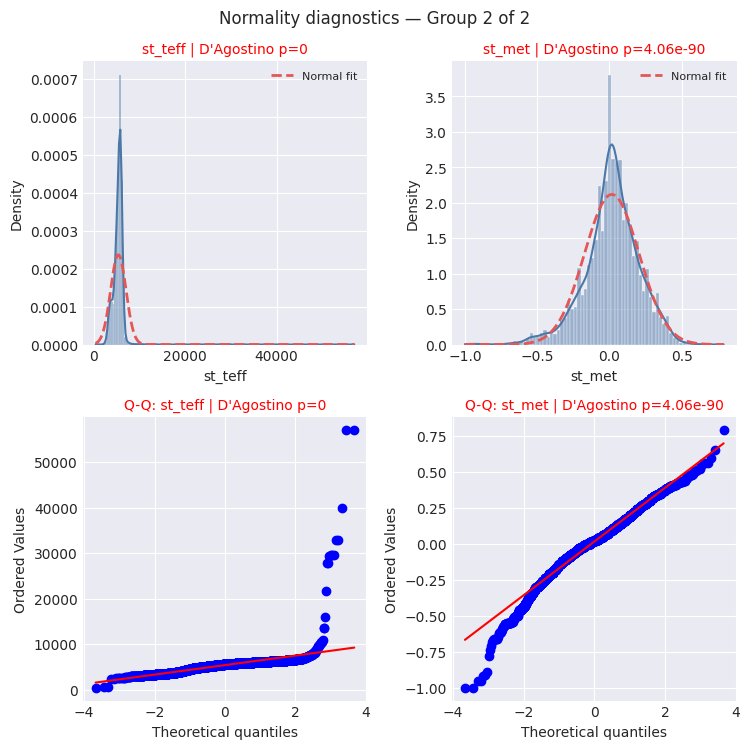

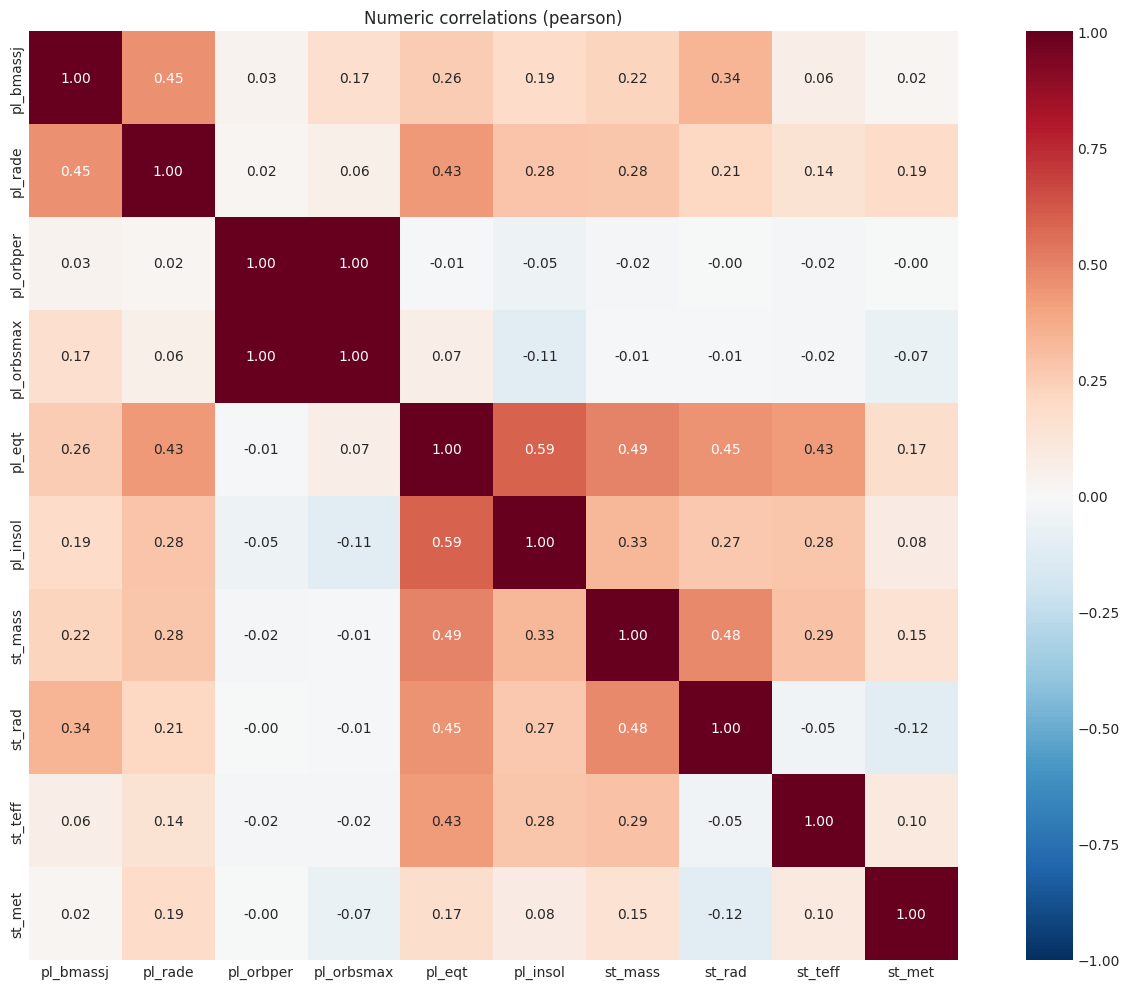


=== Target Correlations ===
  No target column specified; skipping.


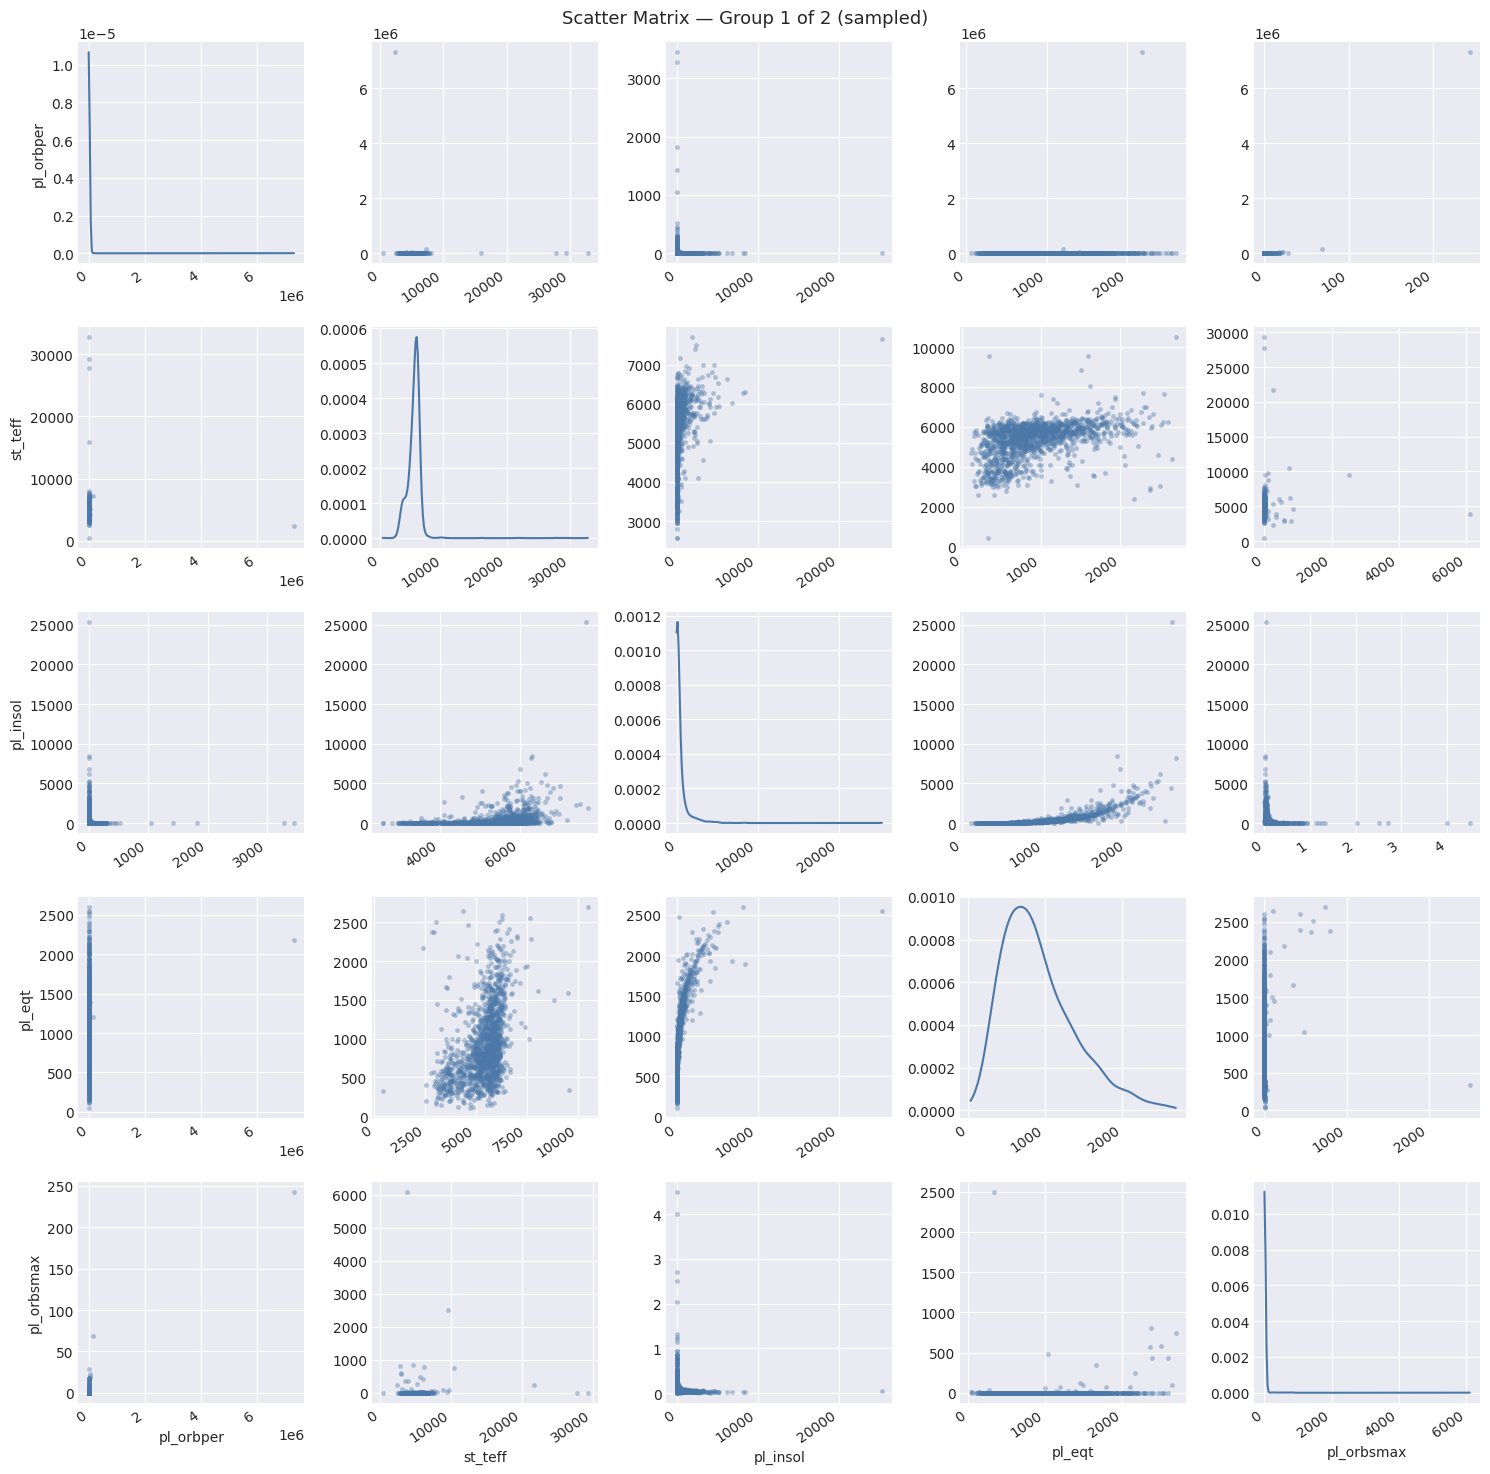

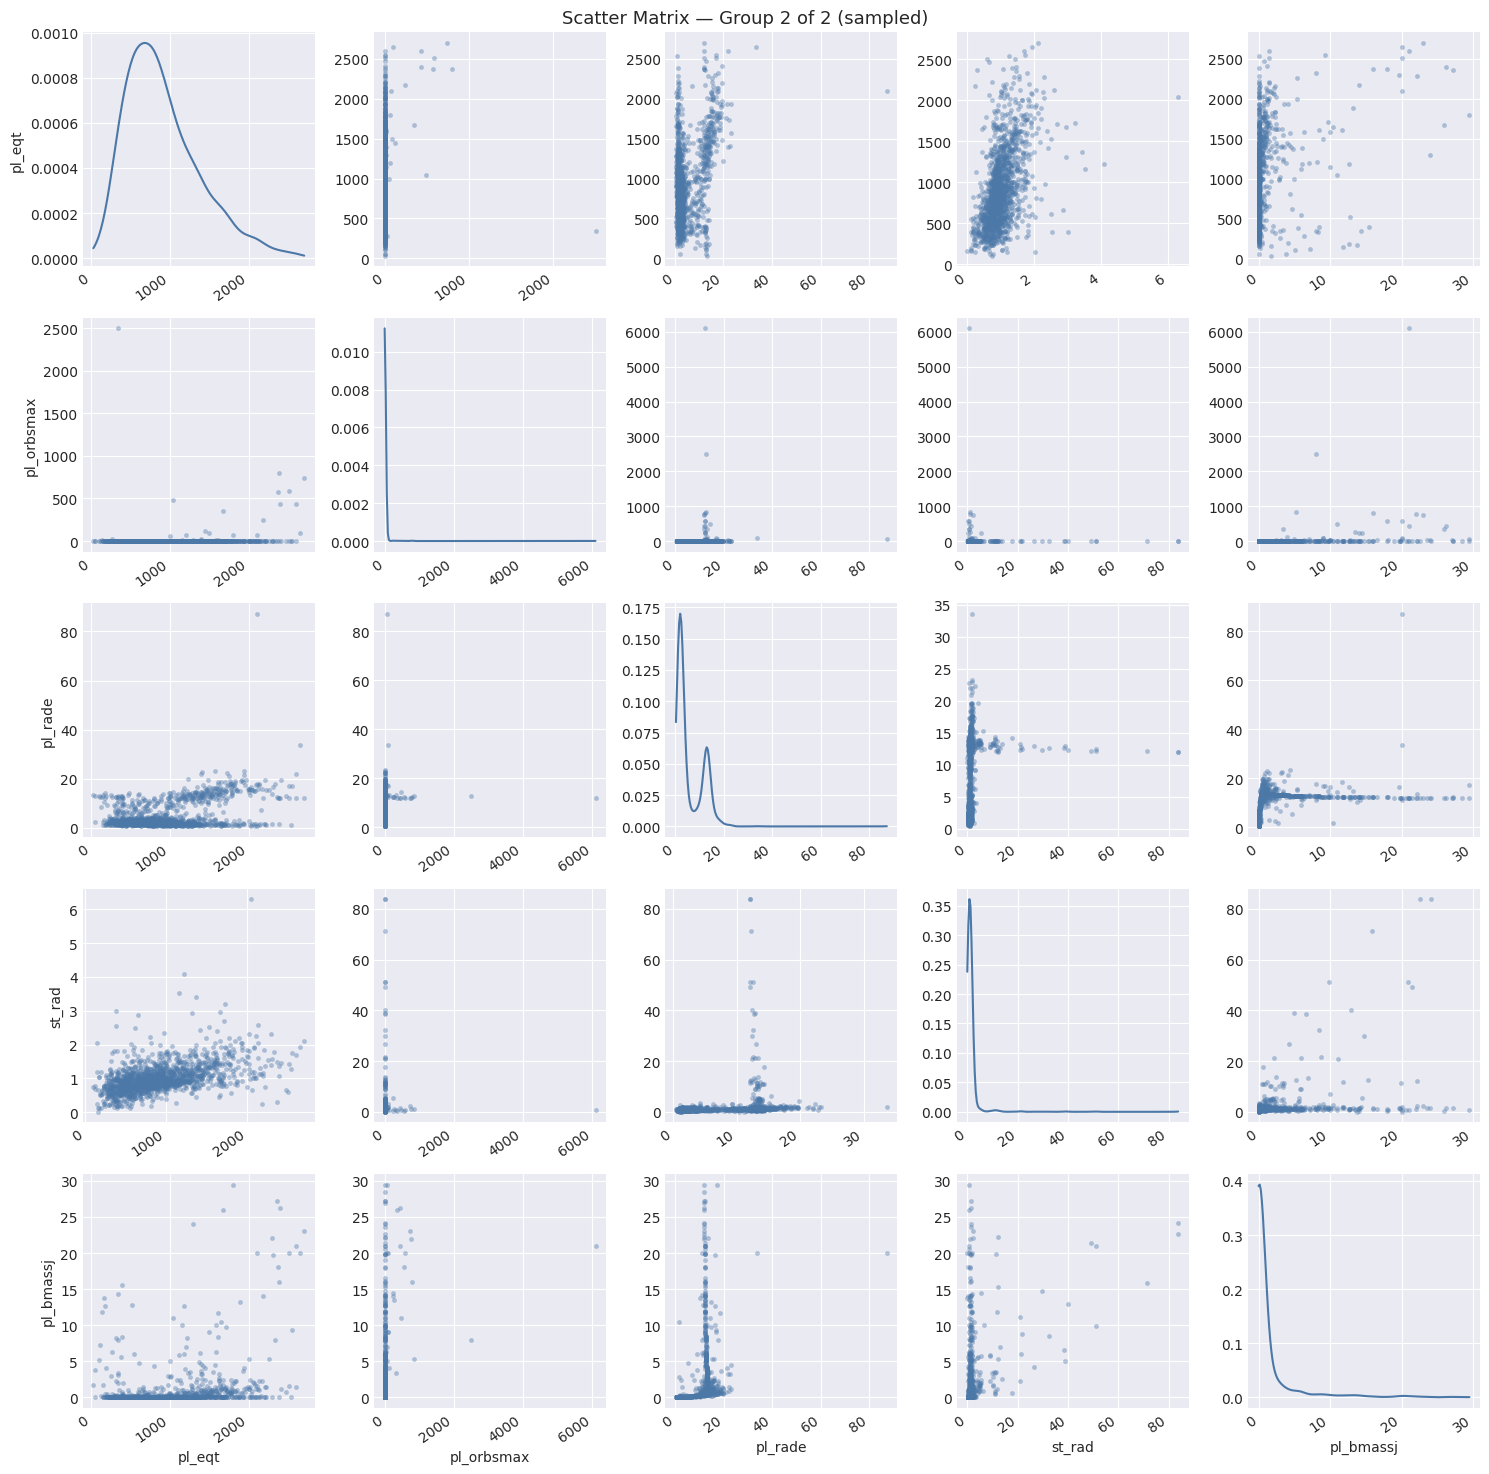

Sweetviz is not installed. Install with: pip install sweetviz

=== Alert Summary ===
severity  category                                                                                                                                                                            message                                                                              affected_columns
 WARNING  outliers                                                                                                                                      Column 'pl_bmassj' has 16.35% outliers (>10%)                                                                                     pl_bmassj
 WARNING  outliers                                                                                                                                      Column 'pl_orbper' has 17.32% outliers (>10%)                                                                                     pl_orbper
 WARNING  outliers                     

In [53]:
full_eda = explorer.run_full_eda()
print("✓ Análisis EDA completo ejecutado exitosamente")
print(f"  Secciones generadas: {len(full_eda)} componentes")